# Prerequisites · M5 — Optimization & Numerical Methods

> **Goal:** the optimization and numerics that make training *actually work* — **gradient descent** and its convergence, **convexity**, the **condition number**, **second-order** methods, and **floating-point** pitfalls (the log-sum-exp trick) — bridging the math foundations to the optimizers (NB04), init (NB05), and mixed precision (NB15).

**Why.** Training is optimization: minimize a loss by descending its gradient. But *how fast* (or whether) that works depends on the loss surface's shape (convexity, conditioning) and on the finite-precision arithmetic underneath. This notebook explains the "why" behind the optimizer behaviors you saw in NB04 and the numerical tricks that keep training from producing NaNs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)


## 1. Gradient descent — and why the negative gradient

**Optimization** = find $\theta$ minimizing a loss $L(\theta)$. **Gradient descent** iterates
$$\theta \leftarrow \theta - \eta\,\nabla L(\theta),$$
stepping in the $-\nabla L$ direction because (from M2) $\nabla L$ points *uphill*, so $-\nabla L$ is the locally steepest way *down*. The **learning rate** $\eta$ sets the step size. This one line — plus the autograd that computes $\nabla L$ — is the entire training loop of every model in this repo.


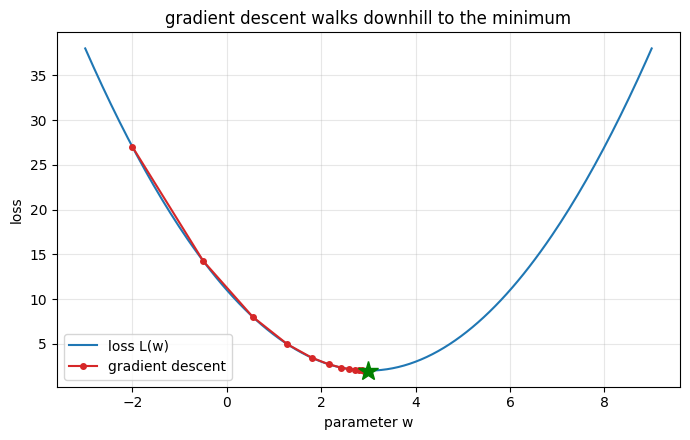

converged to w=2.9960 (true minimum 3.0)


In [2]:
def L(w): return (w-3)**2 + 2                     # a simple 1-D loss, minimum at w=3
def dL(w): return 2*(w-3)
w = -2.0; path=[w]
for _ in range(20):
    w = w - 0.15*dL(w); path.append(w)
ws = np.linspace(-3,9,200)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(ws, L(ws), color="tab:blue", label="loss L(w)")
ax.plot(path, [L(p) for p in path], "-o", color="tab:red", ms=4, label="gradient descent")
ax.plot(3, L(3), "g*", ms=15); ax.set_title("gradient descent walks downhill to the minimum")
ax.set_xlabel("parameter w"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"converged to w={path[-1]:.4f} (true minimum 3.0)")
assert abs(path[-1] - 3.0) < 0.01, \
    f"gradient descent stopped at w={path[-1]:.4f}, not the true minimum 3.0"


**↳ Used in:** the update rule of every optimizer (NB04); this is the "− lr·grad" line you wrote from Notebook 1 onward.


## 2. Convexity — why DL "shouldn't" work but does

A function is **convex** if a line between any two points on it lies *above* the function — a single bowl with **one global minimum** and no traps. Convex problems are "easy": gradient descent provably finds the global optimum. **Neural network losses are non-convex** — a wild landscape of hills, valleys, saddles, and *many* local minima — so classical theory says optimization should get stuck. Yet it works, remarkably well. Understanding this tension (why non-convex optimization succeeds in practice — over-parameterization, good local minima being nearly as good as the global one, SGD noise escaping saddles) is an active research theme (and connects to the generalization mysteries of NB27/28/32).


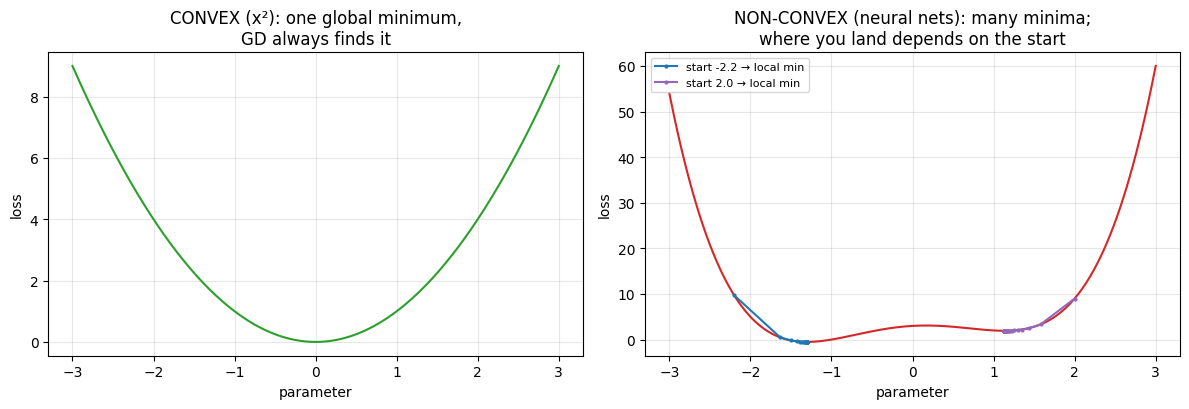

In [3]:
fig, ax = plt.subplots(1,2,figsize=(12,4.2))
xs = np.linspace(-3,3,300)
ax[0].plot(xs, xs**2, color="tab:green"); ax[0].set_title("CONVEX (x²): one global minimum,\nGD always finds it")
# non-convex: multiple minima
def nc(x): return x**4 - 3*x**2 + x + 3
ax[1].plot(xs, nc(xs), color="tab:red")
# show GD from two starts landing in different minima
for w0, col in [(-2.2,"tab:blue"),(2.0,"tab:purple")]:
    w=w0; path=[w]
    for _ in range(50):
        w=w-0.02*(4*w**3-6*w+1); path.append(w)
    ax[1].plot(path,[nc(p) for p in path],"-o",ms=2,color=col,label=f"start {w0} → local min")
ax[1].set_title("NON-CONVEX (neural nets): many minima;\nwhere you land depends on the start"); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel("parameter"); a.set_ylabel("loss"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**↳ Used in:** every training run is non-convex optimization; init (NB05) matters *because* the landscape is non-convex (where you start affects where you land); SGD's noise helps escape saddles.


## 3. The condition number — why SGD zig-zags

For a quadratic bowl, the **condition number** $\kappa = \lambda_{\max}/\lambda_{\min}$ (ratio of the Hessian's largest to smallest eigenvalue, from M2) governs convergence speed. $\kappa=1$ is a perfectly round bowl (GD goes straight to the bottom). Large $\kappa$ is a long, narrow **ravine** — steep across, shallow along — and gradient descent **zig-zags** slowly, because a step size safe for the steep direction is far too small for the shallow one. This is *exactly* the SGD behavior from NB04, now explained: it's the condition number of the loss.


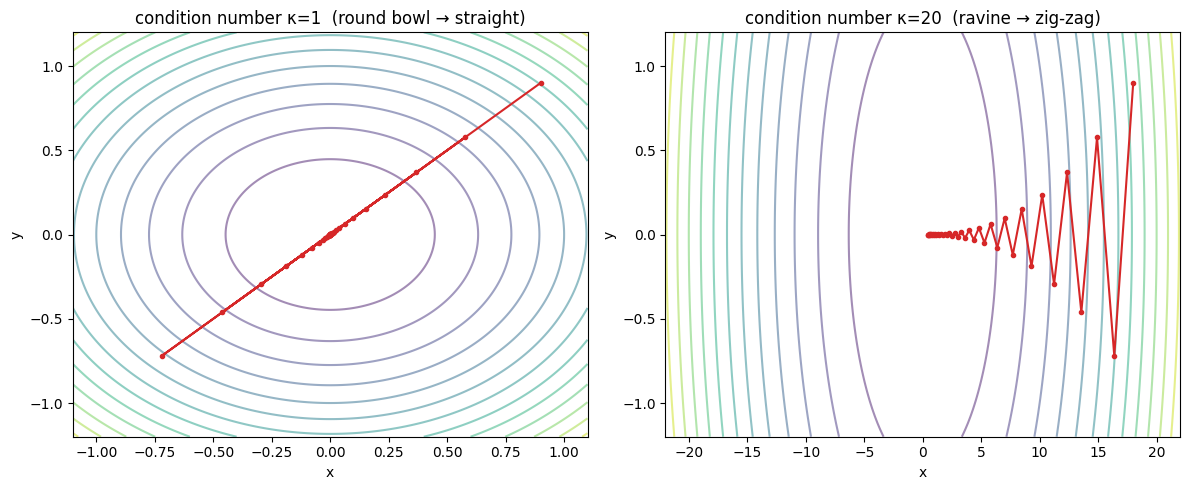

κ=1: GD goes straight down.  κ=20: GD zig-zags — the NB04 problem, explained by the Hessian's eigenvalue spread.


In [4]:
def run_gd(kappa, steps=40, lr=None):
    # quadratic with curvature 1 (x) and kappa (y): L = 0.5(x^2 + kappa y^2)
    lr = lr or 1.8/kappa                         # stable step tied to the steep direction
    p = np.array([kappa*0.9, 0.9]); path=[p.copy()]
    for _ in range(steps):
        p = p - lr*np.array([p[0], kappa*p[1]]); path.append(p.copy())
    return np.array(path)

fig, ax = plt.subplots(1,2,figsize=(12,5))
for a, k in zip(ax,[1, 20]):
    xs=np.linspace(-k*1.1,k*1.1,200); ys=np.linspace(-1.2,1.2,200); X,Y=np.meshgrid(xs,ys)
    a.contour(X,Y,0.5*(X**2+k*Y**2),levels=15,cmap="viridis",alpha=0.5)
    path=run_gd(k); a.plot(path[:,0],path[:,1],"-o",color="tab:red",ms=3)
    a.set_title(f"condition number κ={k}"+("  (round bowl → straight)" if k==1 else "  (ravine → zig-zag)"))
    a.set_xlabel("x"); a.set_ylabel("y")
plt.tight_layout(); plt.show()
print("κ=1: GD goes straight down.  κ=20: GD zig-zags — the NB04 problem, explained by the Hessian's eigenvalue spread.")


**↳ Used in:** why momentum, RMSProp, and Adam exist (NB04) — they all combat ill-conditioning; why good init and normalization (NB05) improve conditioning and speed training.


## 4. Second-order methods — using curvature (and why we mostly don't)

Gradient descent uses only the slope. **Newton's method** also uses the *curvature* (the Hessian $H$), taking the step $\theta \leftarrow \theta - H^{-1}\nabla L$. It rescales the gradient by the inverse curvature, so it heads *straight* to the minimum — on a quadratic it converges in **a single step**, regardless of conditioning. So why isn't all of deep learning Newton's method? Because $H$ is $N\times N$ for $N$ parameters — for a billion-parameter model that's $10^{18}$ entries, impossible to form or invert. So we use **first-order** methods (SGD/Adam) that cheaply *approximate* curvature: Adam's per-parameter $\sqrt{v}$ scaling is a diagonal curvature estimate (NB04).


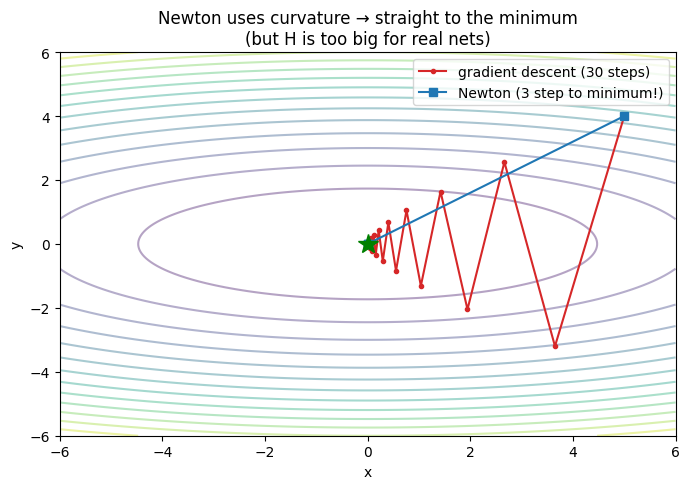

In [5]:
# Newton reaches the minimum of a quadratic in ONE step; GD takes many
A = np.array([[3.0,0.0],[0.0,20.0]])              # Hessian (ill-conditioned)
def grad(p): return A @ p
p0 = np.array([5.0, 4.0])
# GD
p=p0.copy(); gd=[p.copy()]
for _ in range(30): p=p-(1.8/20)*grad(p); gd.append(p.copy())
# Newton: p - H^-1 grad
p=p0.copy(); newton=[p.copy()]
for _ in range(3): p=p-np.linalg.inv(A)@grad(p); newton.append(p.copy())
gd, newton = np.array(gd), np.array(newton)
fig, ax = plt.subplots(figsize=(7,5))
xs=np.linspace(-6,6,200); X,Y=np.meshgrid(xs,xs); ax.contour(X,Y,0.5*(3*X**2+20*Y**2),levels=15,cmap="viridis",alpha=0.4)
ax.plot(gd[:,0],gd[:,1],"-o",color="tab:red",ms=3,label=f"gradient descent ({len(gd)-1} steps)")
ax.plot(newton[:,0],newton[:,1],"-s",color="tab:blue",ms=6,label=f"Newton ({len(newton)-1} step to minimum!)")
ax.plot(0,0,"g*",ms=15); ax.set_title("Newton uses curvature → straight to the minimum\n(but H is too big for real nets)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(); plt.tight_layout(); plt.show()


**↳ Used in:** the *design* of Adam (NB04) as a cheap diagonal curvature approximation; and Muon/second-order-flavored optimizers (NB04 mention).


## 5. Floating point — where training silently breaks

Computers store reals in finite precision, so arithmetic isn't exact. Two failure modes bite deep learning constantly:
- **Overflow / underflow:** $e^x$ overflows for large $x$ (→ `inf`), and probabilities underflow to 0 — which is why we work in **log space** and use the **log-sum-exp trick**.
- **Catastrophic cancellation & the softmax fix:** computing softmax as $e^{z_i}/\sum e^{z_j}$ overflows if any $z$ is large. The fix — subtract the max first, $e^{z_i - \max z}/\sum e^{z_j-\max z}$ — gives the *identical* result but never overflows. You used this in every softmax and cross-entropy in the repo.


In [6]:
z = np.array([1000.0, 1001.0, 1002.0])            # large logits -> naive softmax overflows
def softmax_naive(z): e=np.exp(z); return e/e.sum()
def softmax_stable(z): e=np.exp(z - z.max()); return e/e.sum()   # subtract max: same math, no overflow
print("naive softmax :", softmax_naive(z), " <- overflow: exp(1000)=inf, inf/inf=nan")
print("stable softmax:", softmax_stable(z), " <- correct")

# log-sum-exp: compute log(sum(exp(z))) without overflow
def logsumexp(z): m=z.max(); return m + np.log(np.sum(np.exp(z-m)))
print(f"\nlog(sum(exp([1000,1001,1002]))) = {logsumexp(z):.4f}  (naive would be inf)")
print("This is why loss functions live in log-space and subtract the max — numerical survival.")
assert np.isnan(softmax_naive(z)).all(), "the naive softmax was expected to overflow to nan here"
assert np.isclose(softmax_stable(z).sum(), 1.0) and not np.isnan(softmax_stable(z)).any(), \
    "the stable softmax must return a valid probability distribution"
assert np.isfinite(logsumexp(z)) and abs(logsumexp(z) - 1002.4076) < 1e-3, \
    f"log-sum-exp returned {logsumexp(z)}, expected ~1002.4076"


naive softmax : [nan nan nan]  <- overflow: exp(1000)=inf, inf/inf=nan
stable softmax: [0.09003057 0.24472847 0.66524096]  <- correct

log(sum(exp([1000,1001,1002]))) = 1002.4076  (naive would be inf)
This is why loss functions live in log-space and subtract the max — numerical survival.


C:\Users\sbokk\AppData\Local\Temp\ipykernel_18592\3439281915.py:2: RuntimeWarning: overflow encountered in exp
  def softmax_naive(z): e=np.exp(z); return e/e.sum()
C:\Users\sbokk\AppData\Local\Temp\ipykernel_18592\3439281915.py:2: RuntimeWarning: invalid value encountered in divide
  def softmax_naive(z): e=np.exp(z); return e/e.sum()


**↳ Used in:** the stable softmax/cross-entropy in NB02 and every model since; mixed-precision loss scaling and the fp16 overflow/underflow story (NB15) are the same numerical concerns at 16-bit.

## What you learned
- **Gradient descent** and why $-\nabla L$ (steepest descent); the learning rate.
- **Convexity**: DL is non-convex (many minima) yet trainable — the start (init) matters.
- **Condition number** $\kappa = \lambda_{\max}/\lambda_{\min}$: the cause of SGD's zig-zag (NB04).
- **Second-order / Newton**: uses curvature (one-step on quadratics) but $H$ is too big → we use first-order approximations (Adam).
- **Floating point**: overflow/underflow; the log-sum-exp / subtract-the-max trick that keeps softmax alive.

## Exercises
1. **LR stability bound.** Show GD on a quadratic with curvature $L$ diverges when $\eta > 2/L$; verify empirically (NB04's exercise).
2. **Momentum as conditioning fix.** Show heavy-ball momentum improves the effective condition number; relate to NB04.
3. **Adam ≈ diagonal Newton.** Argue Adam's $1/\sqrt{v}$ is a per-parameter curvature estimate.
4. **Gradient clipping.** Frame clipping (NB09) as a trust-region constraint; when does it help?
5. **Log-space everything.** Reimplement cross-entropy fully in log-space and confirm it matches the stable version.
6. **Catastrophic cancellation.** Find inputs where `(a-b)` loses precision in fp32; relate to accumulation dtype (NB15).

## 📚 References & further reading
- **Convex Optimization** — Boyd & Vandenberghe (2004, free online). The optimization bible (convexity, conditioning, Newton).
- **Deep Learning** — Goodfellow, Bengio & Courville (2016), Chapters 4 & 8 ("Numerical Computation", "Optimization for Training").
- **Numerical Optimization** — Nocedal & Wright. First- and second-order methods, quasi-Newton.
- **What Every Computer Scientist Should Know About Floating-Point Arithmetic** — Goldberg (1991). The floating-point classic.

---
🎉 **This completes the Math Foundations prerequisites (M1–M5).** You now have the linear algebra, calculus, probability, information theory, and optimization/numerics that the rest of the repo (Tiers 0–8) builds on. Next up: **Tier 7 — Reinforcement Learning from scratch.**
